<a href="https://colab.research.google.com/github/Anshu0712-tewatia/Deep-learning/blob/main/DL8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0
# reshape for CNN
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')

])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train_cnn, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1)

test_loss, test_acc = model.evaluate(X_test_cnn, y_test)

print("Test accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9463 - loss: 0.1763 - val_accuracy: 0.9852 - val_loss: 0.0560
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.9878 - val_loss: 0.0424
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.9895 - loss: 0.0341 - val_accuracy: 0.9892 - val_loss: 0.0366
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9882 - val_loss: 0.0396
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.9932 - loss: 0.0193 - val_accuracy: 0.9915 - val_loss: 0.0340
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9922 - val_loss: 0.0329
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.9955 - loss: 0.0127 - val_accuracy: 0.9913 - val_loss: 0.0328
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9975 - loss: 0.0083 - 

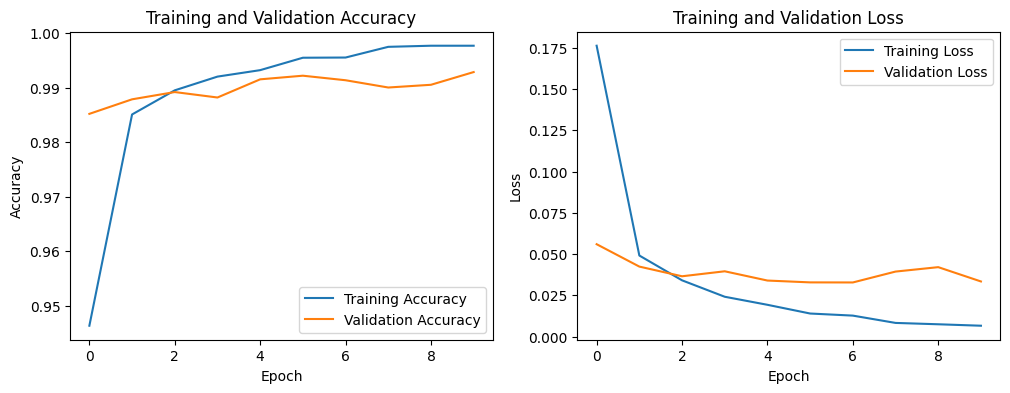

In [3]:
# Plotting accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


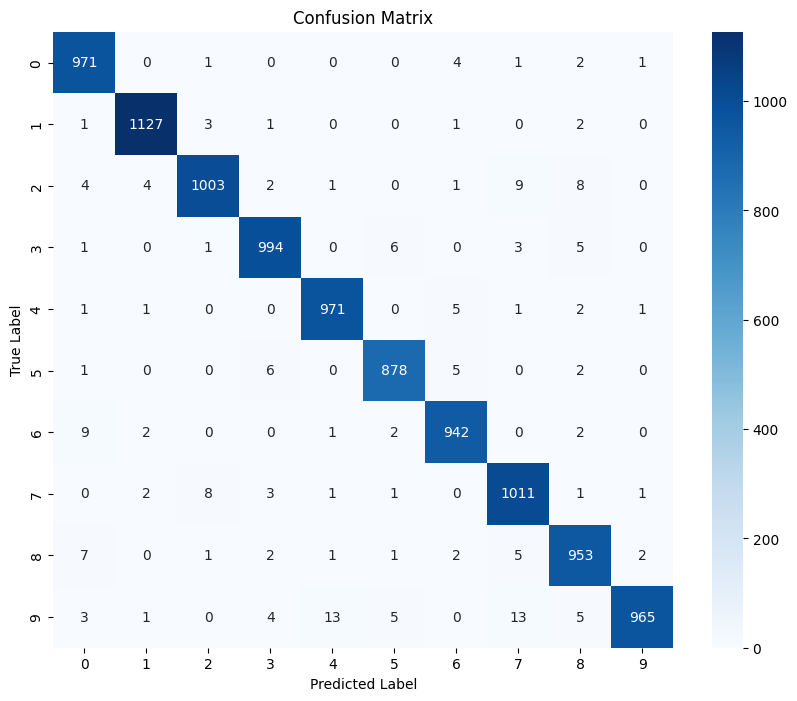

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [4]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0
# reshape for CNN
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')

])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train_cnn, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1)

test_loss, test_acc = model.evaluate(X_test_cnn, y_test)

print("Test accuracy:", test_acc)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.9450 - loss: 0.1902 - val_accuracy: 0.9743 - val_loss: 0.0829
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9806 - loss: 0.0641 - val_accuracy: 0.9838 - val_loss: 0.0610
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 43ms/step - accuracy: 0.9876 - loss: 0.0408 - val_accuracy: 0.9852 - val_loss: 0.0561
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.9914 - loss: 0.0283 - val_accuracy: 0.9862 - val_loss: 0.0568
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9842 - val_loss: 0.0612
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 0.9858 - val_loss: 0.0544
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9970 - loss: 0.0106 - val_accuracy: 0.9883 - val_loss: 0.0527
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9975 - loss: 0.0078 - 

In [5]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0
# reshape for CNN
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),


    Flatten(),

    Dense(10, activation='softmax')

])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train_cnn, y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1)

test_loss, test_acc = model.evaluate(X_test_cnn, y_test)

print("Test accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9242 - loss: 0.2768 - val_accuracy: 0.9750 - val_loss: 0.1003
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9720 - loss: 0.0978 - val_accuracy: 0.9763 - val_loss: 0.0832
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9786 - loss: 0.0722 - val_accuracy: 0.9835 - val_loss: 0.0636
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9826 - loss: 0.0594 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9851 - loss: 0.0502 - val_accuracy: 0.9833 - val_loss: 0.0567
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9865 - loss: 0.0441 - val_accuracy: 0.9855 - val_loss: 0.0539
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9855 - val_loss: 0.0558
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9894 - loss: 0.0349 - 

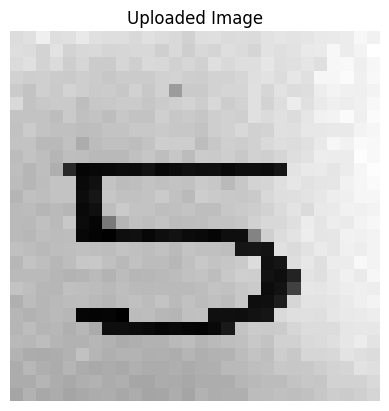

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
img_path = "/content/dlimage.png"

img = image.load_img(img_path, color_mode="grayscale", target_size=(28,28))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

plt.imshow(img_array.squeeze(), cmap='gray')
plt.title("Uploaded Image")
plt.axis("off")
plt.show()